# Extract and Inspect Windowed Multimodal Features

In [2]:
%matplotlib inline
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from data_processing.feature_extraction import run_all

WORKSPACE_DIR = os.getcwd()
FEATURES_DIR = os.path.join(WORKSPACE_DIR, 'features')

In [3]:
outputs = run_all()
outputs

Found 14 PPG signal files under c:\Users\dimi_cuceritorul\ac-hri_cw\data_collection_and_label_synch\data\labelled_data
Processing: 001 : full_labelled_001-easy.csv
Processing: 001 : full_labelled_001-hard.csv
Processing: 002 : full_labelled_002-easy.csv
Processing: 002 : full_labelled_002-hard.csv


c:\Users\dimi_cuceritorul\ac-hri_cw\.venv\Lib\site-packages\numpy\_core\fromnumeric.py:3824: RuntimeWarning: Mean of empty slice
  return _methods._mean(a, axis=axis, dtype=dtype,
c:\Users\dimi_cuceritorul\ac-hri_cw\.venv\Lib\site-packages\numpy\_core\_methods.py:219: RuntimeWarning: Degrees of freedom <= 0 for slice
  ret = _var(a, axis=axis, dtype=dtype, out=out, ddof=ddof,
c:\Users\dimi_cuceritorul\ac-hri_cw\.venv\Lib\site-packages\numpy\ma\core.py:5403: RuntimeWarning: Mean of empty slice
  result = super().mean(axis=axis, dtype=dtype, **kwargs)[()]
c:\Users\dimi_cuceritorul\ac-hri_cw\.venv\Lib\site-packages\numpy\_core\fromnumeric.py:4232: RuntimeWarning: Degrees of freedom <= 0 for slice
  return _methods._var(a, axis=axis, dtype=dtype, out=out, ddof=ddof,


Processing: 003 : full_labelled_003-easy.csv
Processing: 003 : full_labelled_003-hard.csv
Processing: 004 : full_labelled_004-easy.csv
Processing: 004 : full_labelled_004-hard.csv
Processing: 005 : full_labelled_005-easy.csv
Processing: 005 : full_labelled_005-hard.csv
Processing: 006 : full_labelled_006-easy.csv
Processing: 006 : full_labelled_006-hard.csv
Processing: 007 : full_labelled_007-easy.csv
Processing: 007 : full_labelled_007-hard.csv
Wrote 70 window rows to c:\Users\dimi_cuceritorul\ac-hri_cw\emotion_recognition_system\features\PPG_features_windowed.csv
Wrote 121 EDA window rows to c:\Users\dimi_cuceritorul\ac-hri_cw\emotion_recognition_system\features\EDA_features_windowed.csv
Wrote merged features to c:\Users\dimi_cuceritorul\ac-hri_cw\emotion_recognition_system\features\combined_features_windowed.csv
Wrote quality report to c:\Users\dimi_cuceritorul\ac-hri_cw\emotion_recognition_system\features\quality_report.txt


{'ppg_window_csv': 'c:\\Users\\dimi_cuceritorul\\ac-hri_cw\\emotion_recognition_system\\features\\PPG_features_windowed.csv',
 'eda_window_csv': 'c:\\Users\\dimi_cuceritorul\\ac-hri_cw\\emotion_recognition_system\\features\\EDA_features_windowed.csv',
 'combined_csv': 'c:\\Users\\dimi_cuceritorul\\ac-hri_cw\\emotion_recognition_system\\features\\combined_features_windowed.csv'}

In [4]:
combined_path = os.path.join(FEATURES_DIR, 'combined_features_windowed.csv')
df = pd.read_csv(combined_path)
print('shape:', df.shape)
df.dtypes

shape: (121, 28)


sub_id                    int64
label                       str
window_index              int64
window_start_sec_ppg    float64
status_ppg                  str
bpm                     float64
ibi                     float64
sdnn                    float64
sdsd                        str
rmssd                   float64
pnn20                   float64
pnn50                   float64
hr_mad                  float64
sd1                     float64
sd2                     float64
s                       float64
sd1/sd2                 float64
breathingrate           float64
window_start_sec_eda    float64
status_eda                  str
eda_mean_scl            float64
eda_slope_scl           float64
eda_num_scr               int64
eda_mean_scr_amp        float64
eda_sum_scr_amp         float64
eda_variance            float64
eda_range               float64
eda_deriv_mean          float64
dtype: object

In [5]:
display(df.groupby(['sub_id', 'label']).size().rename('n_windows').reset_index())
display(df.describe(include='all').transpose())

,sub_id,label,n_windows
0,1,easy,13
1,1,hard,11
2,2,easy,12
3,2,hard,9
4,3,easy,7
5,3,hard,9
6,4,easy,9
7,4,hard,8
8,5,easy,6
9,5,hard,10


,count,unique,top,freq,mean,std,min,25%,50%,75%,max
sub_id,121.0,NaN,NaN,NaN,3.61157,2.014001,1.0,2.0,3.0,5.0,7.0
label,121,2,easy,61,NaN,NaN,NaN,NaN,NaN,NaN,NaN
window_index,121.0,NaN,NaN,NaN,4.090909,2.94392,0.0,2.0,4.0,6.0,12.0
window_start_sec_ppg,70.0,NaN,NaN,NaN,41.550446,38.613545,0.0,15.0,30.0,60.0,159.28125
status_ppg,70,2,ok,55,NaN,NaN,NaN,NaN,NaN,NaN,NaN
bpm,52.0,NaN,NaN,NaN,105.160274,36.999118,44.137931,75.294118,98.059568,127.543798,180.601388
ibi,52.0,NaN,NaN,NaN,643.9967,229.05916,332.223361,470.525568,611.907115,796.875,1359.375
sdnn,52.0,NaN,NaN,NaN,141.552074,48.334858,0.0,129.451656,148.967886,169.668827,217.09193
sdsd,55,44,--,7,NaN,NaN,NaN,NaN,NaN,NaN,NaN
rmssd,48.0,NaN,NaN,NaN,220.36781,80.009318,31.25,181.156594,205.429,260.75443,445.381025


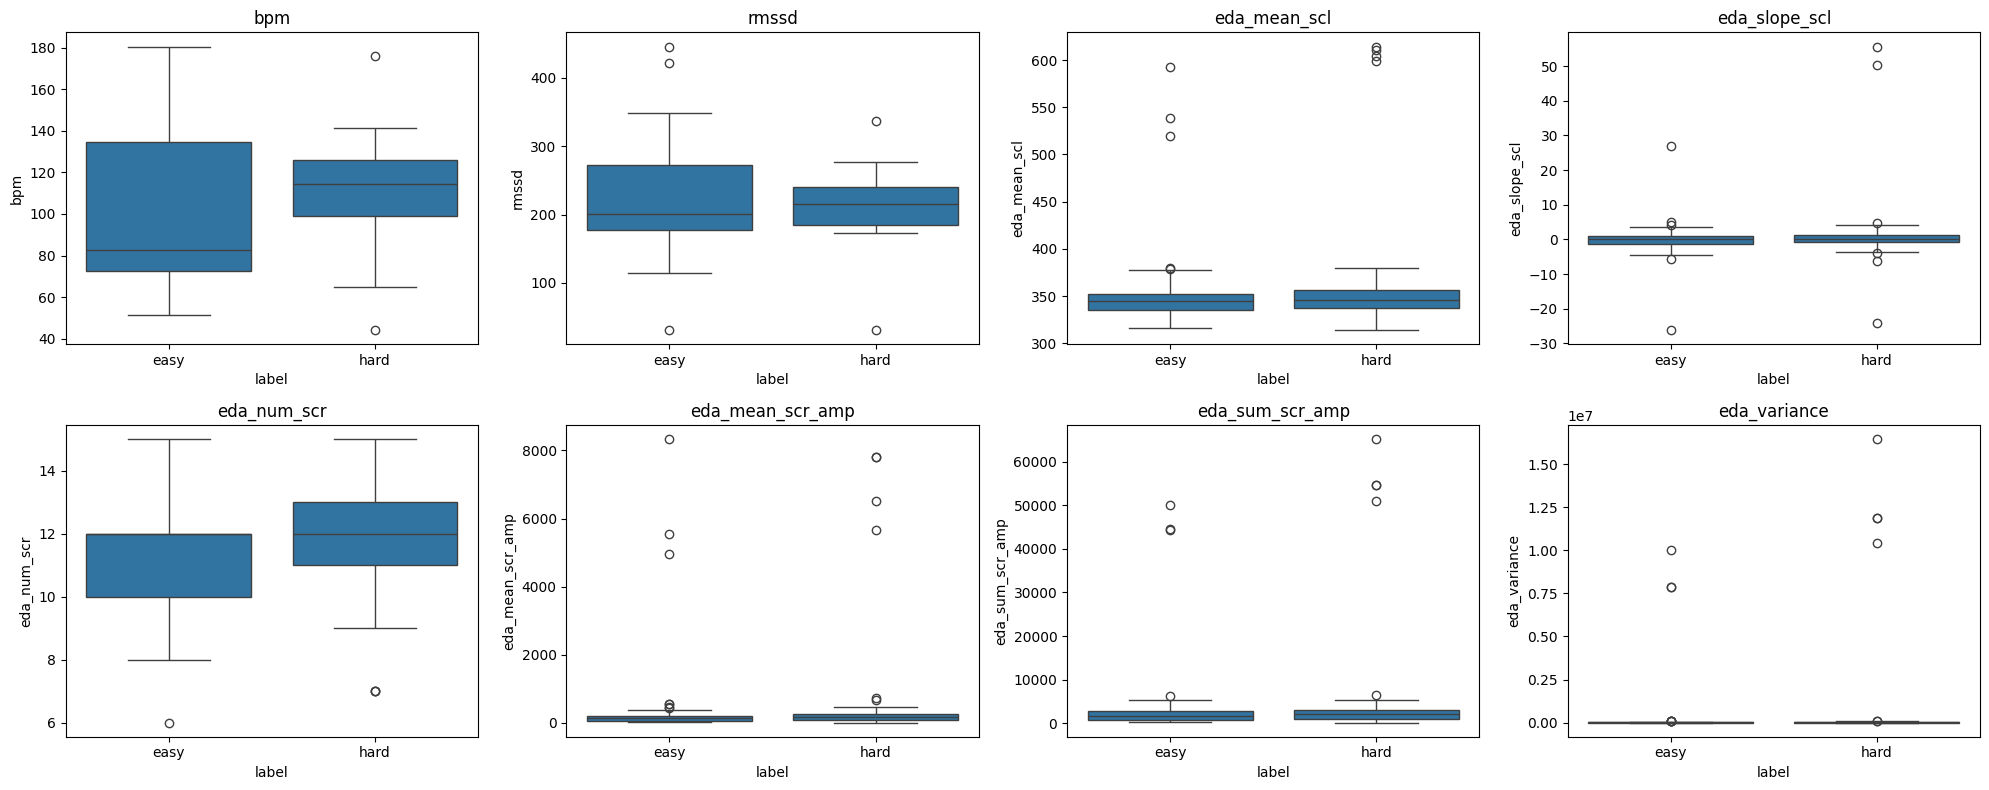

In [6]:
plot_cols = [c for c in df.columns if c.startswith('bpm') or c.startswith('rmssd') or c.startswith('eda_')]
plot_cols = plot_cols[:8]
fig, axes = plt.subplots(2, 4, figsize=(20, 8))
axes = axes.ravel()
for idx, col in enumerate(plot_cols):
    sns.boxplot(data=df, x='label', y=col, ax=axes[idx])
    axes[idx].set_title(col)
for idx in range(len(plot_cols), len(axes)):
    axes[idx].axis('off')
plt.tight_layout()

Text(120.72222222222221, 0.5, 'Rows')

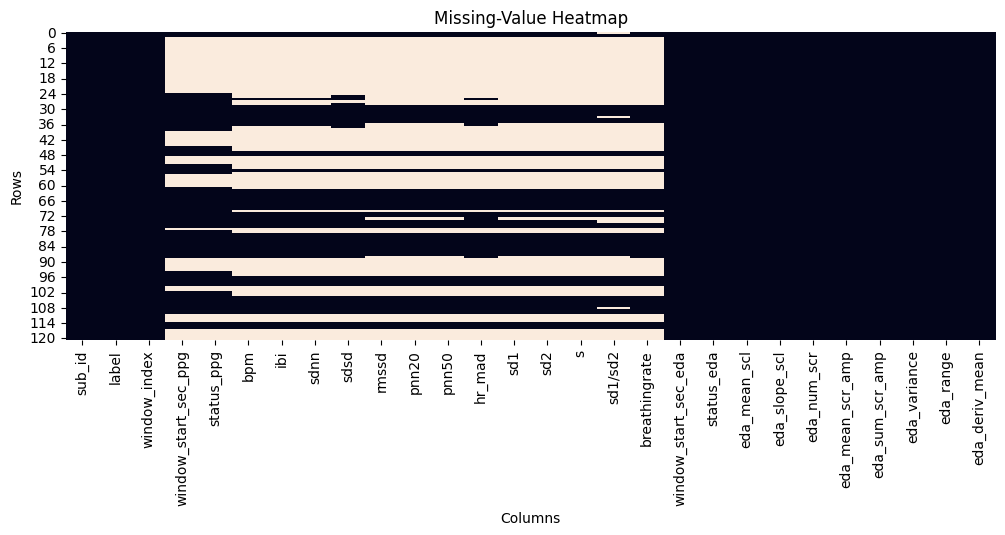

In [7]:
plt.figure(figsize=(12, 4))
sns.heatmap(df.isna(), cbar=False)
plt.title('Missing-Value Heatmap')
plt.xlabel('Columns')
plt.ylabel('Rows')

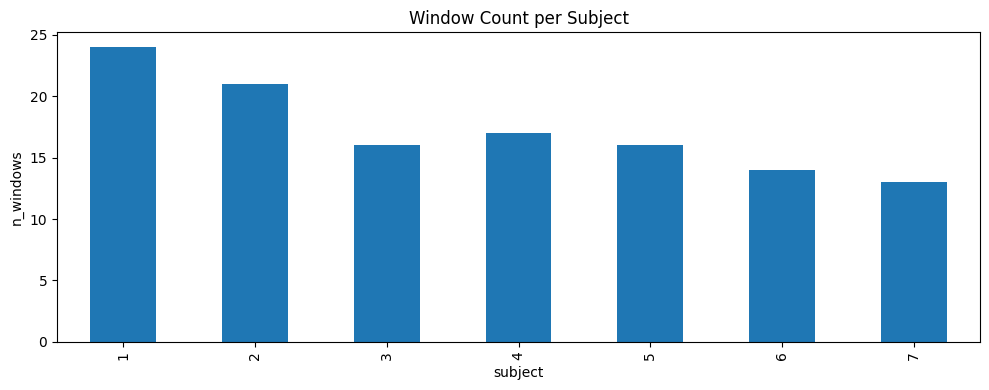

In [8]:
window_counts = df.groupby('sub_id').size().sort_index()
plt.figure(figsize=(10, 4))
window_counts.plot(kind='bar')
plt.title('Window Count per Subject')
plt.ylabel('n_windows')
plt.xlabel('subject')
plt.tight_layout()

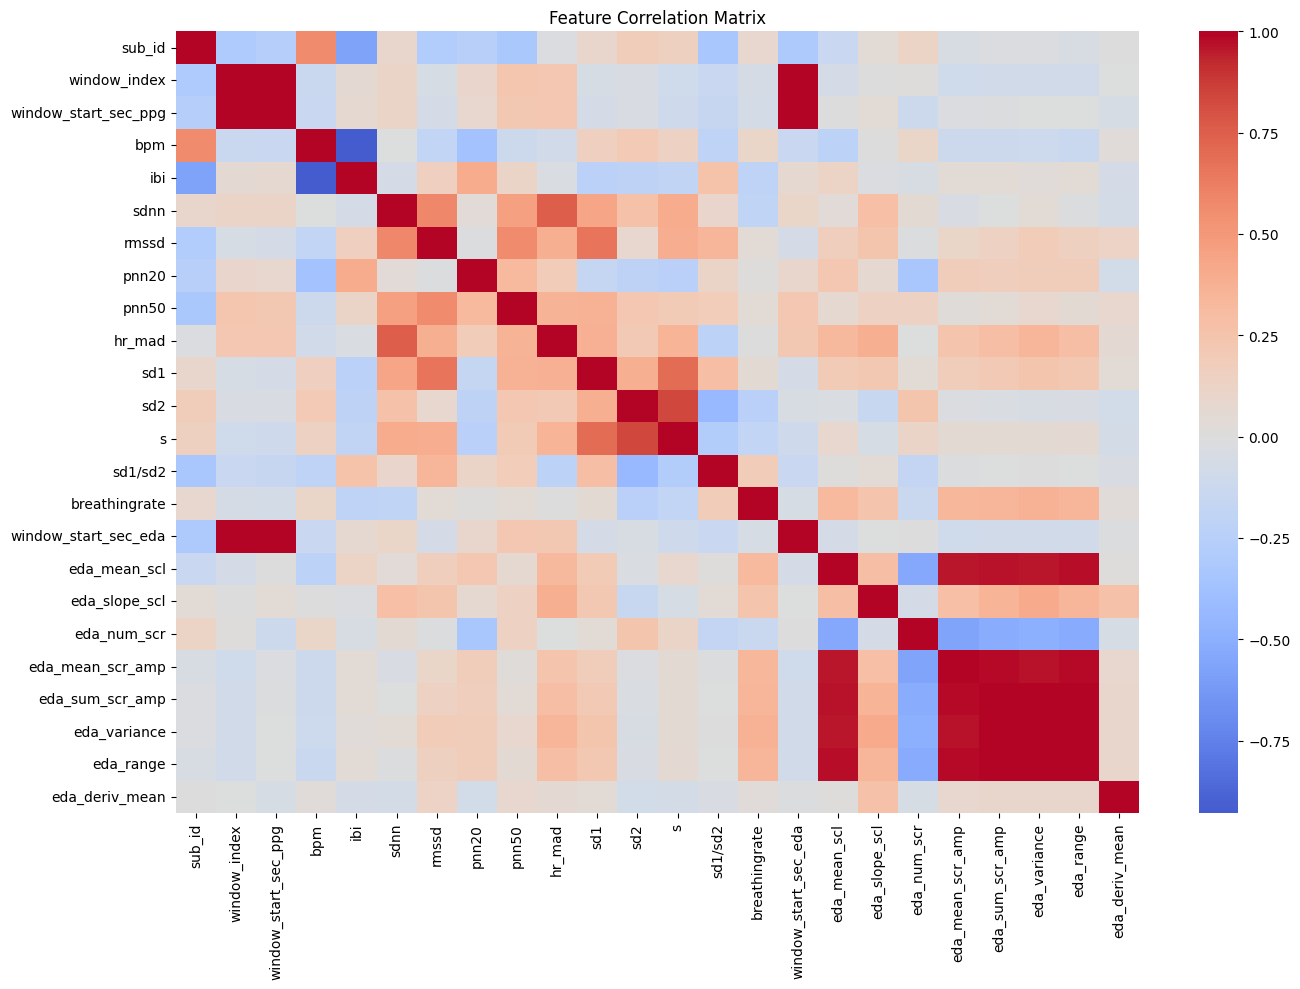

In [9]:
num_df = df.select_dtypes(include=[np.number]).copy()
corr = num_df.corr(numeric_only=True)
plt.figure(figsize=(14, 10))
sns.heatmap(corr, cmap='coolwarm', center=0)
plt.title('Feature Correlation Matrix')
plt.tight_layout()